# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [83]:
pip install kagglehub

In [84]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [44]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Dataset downloaded to:", path)

for file in os.listdir(path):
    print(file)

df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

df.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset downloaded to: /kaggle/input/telco-customer-churn
WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Shape:", df.shape)
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

# Informasi Dataset

In [ ]:
df.info()

# Statistik Deskriptif

In [47]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [48]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


# Missing Value

In [49]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [50]:
(df == " ").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# Cek data duplikat

In [51]:
duplicate_count = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 0


# Distribusi Target (Churn)

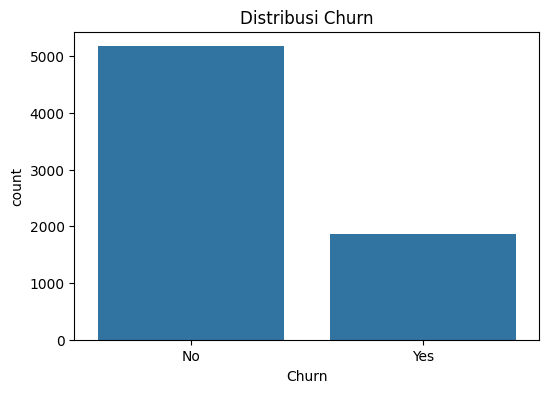

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Distribusi Churn')
plt.show()

# Distribusi Variabel Numerik

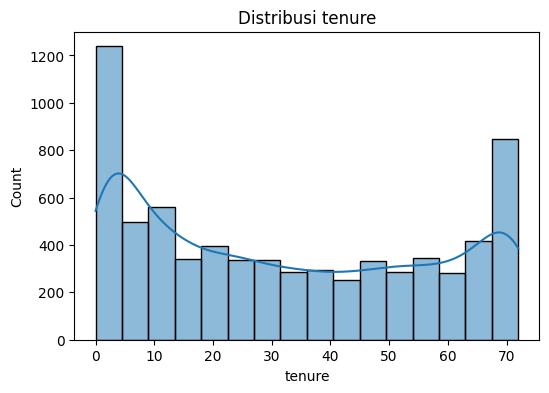

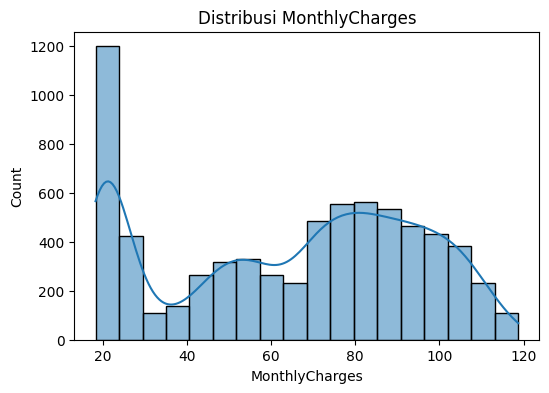

In [53]:
num_cols = ['tenure', 'MonthlyCharges']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.show()

# Churn vs Tenure

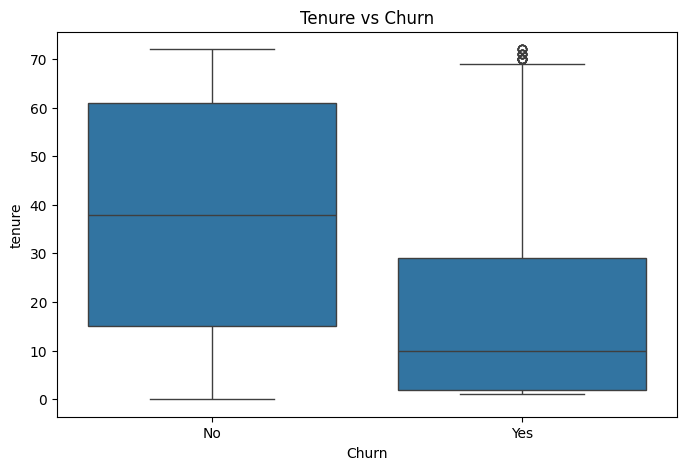

In [54]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')
plt.show()

# Churn vs Monthly Charges

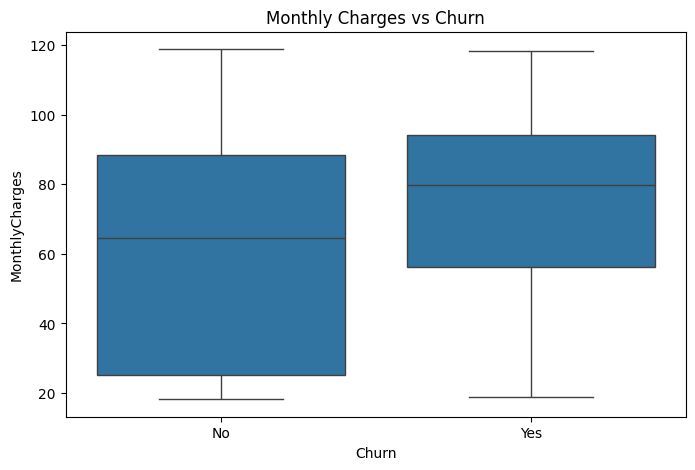

In [55]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.show()

# Korelasi Fitur Numerik

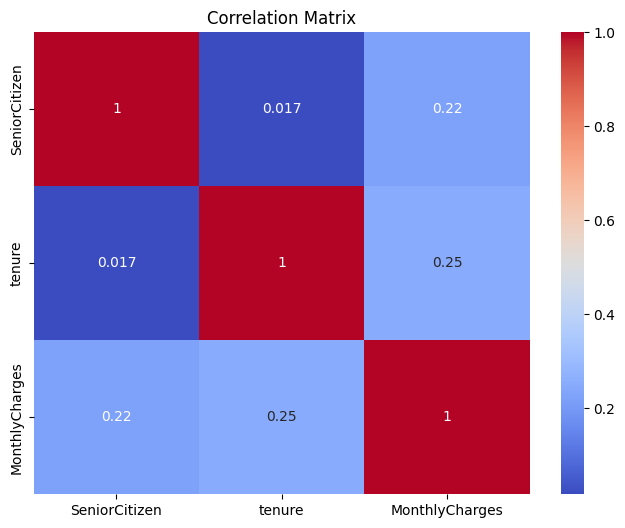

In [56]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Matrix')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

# Drop customerID

In [57]:
df.drop(columns=["customerID"], inplace=True)

In [58]:
print("Shape sesudah:", df.shape)

df.head()

Shape sesudah: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [59]:
print("customerID" in df.columns)

False


# Bersihkan TotalCharges

In [60]:
print("Blank values TotalCharges:")
print((df["TotalCharges"] == " ").sum())

Blank values TotalCharges:
11


In [61]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [62]:
print(df["TotalCharges"].dtype)

print(df["TotalCharges"].isnull().sum())

float64
11


# Tangani Missing Value

In [63]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [64]:
df.dropna(inplace=True)

In [65]:
print("Shape setelah dropna:")
print(df.shape)

print("Missing values:")
print(df.isnull().sum().sum())

Shape setelah dropna:
(7032, 20)
Missing values:
0


# Encoding Target

In [66]:
print(df["Churn"].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [67]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [68]:
print(df["Churn"].value_counts())

df["Churn"].head()

Churn
0    5163
1    1869
Name: count, dtype: int64


,Churn
0,0
1,0
2,1
3,0
4,1


# Encoding Fitur Kategorikal

In [69]:
print(df.shape)

df.select_dtypes(include="object").columns

(7032, 20)


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [70]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [71]:
print(df.shape)

df.head()

(7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [72]:
df.columns.tolist()[:20]

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'gender_Male',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service']

# Pisahkan X dan y

In [73]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [74]:
print("Shape X:", X.shape)

print("Shape y:", y.shape)

X.head()

Shape X: (7032, 30)
Shape y: (7032,)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


# Train Test Split

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [76]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 30)
X_test : (1407, 30)
y_train: (5625,)
y_test : (1407,)


In [77]:
print(y_train.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))

Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


# Standardisasi

In [78]:
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_train[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,5625.000000,5625.000000,5625.000000
mean,32.562311,64.999316,2301.839520
std,24.542421,30.108642,2275.586084
min,1.000000,18.400000,18.800000
25%,9.000000,35.800000,413.000000
50%,29.000000,70.600000,1410.250000
75%,56.000000,90.050000,3801.700000
max,72.000000,118.650000,8684.800000


In [79]:
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [80]:
X_train[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.625000e+03,5.625000e+03,5.625000e+03
mean,-1.291609e-16,3.157968e-17,8.842310e-18
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.286145e+00,-1.547843e+00,-1.003365e+00
25%,-9.601500e-01,-9.698847e-01,-8.301191e-01
50%,-1.451620e-01,1.860324e-01,-3.918414e-01
75%,9.550717e-01,8.320837e-01,6.591681e-01
max,1.607062e+00,1.782062e+00,2.805224e+00


In [81]:
print("Final Dataset")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTarget Distribution")

print(y_train.value_counts())

Final Dataset
X_train: (5625, 30)
X_test : (1407, 30)

Target Distribution
Churn
0    4130
1    1495
Name: count, dtype: int64


In [82]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1413,0,1.321816,0.981556,1.659900,True,True,True,True,False,True,...,False,False,False,False,False,True,False,True,False,False
7003,0,-0.267410,-0.971546,-0.562252,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3355,0,1.444064,0.837066,1.756104,False,True,False,True,False,True,...,False,False,False,False,False,True,False,True,False,False
4494,0,-1.204646,0.641092,-0.908326,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
3541,0,0.669826,-0.808787,-0.101561,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False


# SIMPAN DATASET HASIL PREPOCESSING

In [86]:
os.makedirs("dataset_preprocessing", exist_ok=True)

processed_df.to_csv(
    "dataset_preprocessing/train_processed.csv",
    index=False
)

In [87]:
test_df = pd.concat(
    [X_test, y_test],
    axis=1
)

test_df.to_csv(
    "dataset_preprocessing/test_processed.csv",
    index=False
)

In [88]:
processed_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
1413,0,1.321816,0.981556,1.659900,True,True,True,True,False,True,...,False,False,False,False,True,False,True,False,False,0
7003,0,-0.267410,-0.971546,-0.562252,True,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,0
3355,0,1.444064,0.837066,1.756104,False,True,False,True,False,True,...,False,False,False,False,True,False,True,False,False,0
4494,0,-1.204646,0.641092,-0.908326,True,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,0
3541,0,0.669826,-0.808787,-0.101561,False,True,False,False,True,False,...,True,False,False,False,False,False,False,False,False,0


In [93]:
def load_data(filepath):
    """
    Load dataset
    """
    df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
    print(f"Dataset loaded: {df.shape}")
    return df


def clean_data(df):
    """
    Data cleaning
    """
    # Drop customerID
    df.drop(columns=["customerID"], inplace=True)

    # Handle blank values
    df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)

    # Convert datatype
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

    # Remove missing values
    df.dropna(inplace=True)

    print(f"After cleaning: {df.shape}")

    return df


def encode_data(df):
    """
    Encoding target and categorical features
    """

    # Encode target
    df["Churn"] = df["Churn"].map({
        "No": 0,
        "Yes": 1
    })

    # One-hot encoding
    df = pd.get_dummies(
        df,
        drop_first=True
    )

    print(f"After encoding: {df.shape}")

    return df


def split_data(df):
    """
    Split features and target
    """

    X = df.drop("Churn", axis=1)
    y = df["Churn"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print("Train shape:", X_train.shape)
    print("Test shape :", X_test.shape)

    return X_train, X_test, y_train, y_test


def scale_data(X_train, X_test):
    """
    Standardization
    """

    numeric_cols = [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]

    scaler = StandardScaler()

    X_train[numeric_cols] = scaler.fit_transform(
        X_train[numeric_cols]
    )

    X_test[numeric_cols] = scaler.transform(
        X_test[numeric_cols]
    )

    return X_train, X_test


def save_data(X_train, X_test, y_train, y_test):
    """
    Save processed dataset
    """

    os.makedirs(
        "dataset_preprocessing",
        exist_ok=True
    )

    train_df = pd.concat(
        [X_train, y_train],
        axis=1
    )

    test_df = pd.concat(
        [X_test, y_test],
        axis=1
    )

    train_df.to_csv(
        "dataset_preprocessing/train_processed.csv",
        index=False
    )

    test_df.to_csv(
        "dataset_preprocessing/test_processed.csv",
        index=False
    )

    print("Processed dataset saved.")


def main():

    filepath = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

    df = load_data(filepath)

    df = clean_data(df)

    df = encode_data(df)

    X_train, X_test, y_train, y_test = split_data(df)

    X_train, X_test = scale_data(
        X_train,
        X_test
    )

    save_data(
        X_train,
        X_test,
        y_train,
        y_test
    )


if __name__ == "__main__":
    main()


Dataset loaded: (7043, 21)
After cleaning: (7032, 20)
After encoding: (7032, 31)
Train shape: (5625, 30)
Test shape : (1407, 30)
Processed dataset saved.


In [94]:
%%writefile automate_nama.py

import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def load_data(filepath):
    df = pd.read_csv(filepath)
    print(f"Dataset loaded: {df.shape}")
    return df


def clean_data(df):
    """
    Data cleaning
    """
    # Drop customerID
    df.drop(columns=["customerID"], inplace=True)

    # Handle blank values
    df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)

    # Convert datatype
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

    # Remove missing values
    df.dropna(inplace=True)

    print(f"After cleaning: {df.shape}")

    return df


def encode_data(df):
    """
    Encoding target and categorical features
    """

    # Encode target
    df["Churn"] = df["Churn"].map({
        "No": 0,
        "Yes": 1
    })

    # One-hot encoding
    df = pd.get_dummies(
        df,
        drop_first=True
    )

    print(f"After encoding: {df.shape}")

    return df


def split_data(df):
    """
    Split features and target
    """

    X = df.drop("Churn", axis=1)
    y = df["Churn"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print("Train shape:", X_train.shape)
    print("Test shape :", X_test.shape)

    return X_train, X_test, y_train, y_test


def scale_data(X_train, X_test):
    """
    Standardization
    """

    numeric_cols = [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]

    scaler = StandardScaler()

    X_train[numeric_cols] = scaler.fit_transform(
        X_train[numeric_cols]
    )

    X_test[numeric_cols] = scaler.transform(
        X_test[numeric_cols]
    )

    return X_train, X_test


def save_data(X_train, X_test, y_train, y_test):
    """
    Save processed dataset
    """

    os.makedirs(
        "dataset_preprocessing",
        exist_ok=True
    )

    train_df = pd.concat(
        [X_train, y_train],
        axis=1
    )

    test_df = pd.concat(
        [X_test, y_test],
        axis=1
    )

    train_df.to_csv(
        "dataset_preprocessing/train_processed.csv",
        index=False
    )

    test_df.to_csv(
        "dataset_preprocessing/test_processed.csv",
        index=False
    )

    print("Processed dataset saved.")


def main():

    filepath = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

    df = load_data(filepath)

    df = clean_data(df)

    df = encode_data(df)

    X_train, X_test, y_train, y_test = split_data(df)

    X_train, X_test = scale_data(
        X_train,
        X_test
    )

    save_data(
        X_train,
        X_test,
        y_train,
        y_test
    )


if __name__ == "__main__":
    main()


Writing automate_nama.py


In [96]:
processed_df = pd.concat(
    [X, y],
    axis=1
)

processed_df.to_csv(
    "dataset_preprocessing/telco_preprocessed.csv",
    index=False
)